In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import pandas as pd
train_path = './data/KDDTrain+.txt'
test_path = './data/KDDTest+.txt'
COL_NAMES = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label", "difficulty_level"]

# Try loading with error handling for paths
try:
    df_train = pd.read_csv(train_path, header=None, names=COL_NAMES)
    df_test = pd.read_csv(test_path, header=None, names=COL_NAMES)
    print(f"Training Data Shape: {df_train.head()}")
    print(f"Test Data Shape: {df_test.tail()}")
except FileNotFoundError:
    print("Files not found. Please check the paths. Trying absolute paths or checking local directory...")
    # Fallback to local directory if paths are different
    if os.path.exists('KDDTrain+.txt'):
        df_train = pd.read_csv('KDDTrain+.txt', header=None, names=COL_NAMES)
        df_test = pd.read_csv('KDDTest+.txt', header=None, names=COL_NAMES)


Training Data Shape:    duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0

In [3]:
from sklearn.preprocessing import OneHotEncoder

cols_to_encode = ['protocol_type', 'flag']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train
ohe.fit(df_train[cols_to_encode])

# Transform train & test directly
train_encoded = pd.DataFrame(
    ohe.transform(df_train[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_train.index
)

test_encoded = pd.DataFrame(
    ohe.transform(df_test[cols_to_encode]),
    columns=ohe.get_feature_names_out(cols_to_encode),
    index=df_test.index
)

# Frequency encoding
freq_map = df_train['service'].value_counts(normalize=True)

df_train['service_freq'] = df_train['service'].map(freq_map)
df_test['service_freq'] = df_test['service'].map(freq_map).fillna(0)

# Final datasets
df_train_encode = pd.concat([df_train, train_encoded], axis=1)
df_test_encode = pd.concat([df_test, test_encoded], axis=1)
df_train_encode

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df_train_encode.drop(columns=['protocol_type','flag','service'],inplace = True)
df_test_encode.drop(columns=['protocol_type','flag','service'],inplace = True)

In [5]:
categorical_features = ['protocol_type','service','flag']
binary_features = ['land','logged_in','is_host_login','is_guest_login']
#All the other numerical values

numerical_features = [col for col in COL_NAMES if col not in categorical_features + binary_features +['label','difficulty_level']]

print(f"Categorical Features: {len(categorical_features)}")
print(f"Binary Features: {len(binary_features)}")
print(f"Numerical Features: {len(numerical_features)}")

print(df_train.isnull())

Categorical Features: 3
Binary Features: 4
Numerical Features: 34
        duration  protocol_type  service   flag  src_bytes  dst_bytes   land  \
0          False          False    False  False      False      False  False   
1          False          False    False  False      False      False  False   
2          False          False    False  False      False      False  False   
3          False          False    False  False      False      False  False   
4          False          False    False  False      False      False  False   
...          ...            ...      ...    ...        ...        ...    ...   
125968     False          False    False  False      False      False  False   
125969     False          False    False  False      False      False  False   
125970     False          False    False  False      False      False  False   
125971     False          False    False  False      False      False  False   
125972     False          False    False  False      F

In [6]:
# Mapping Dictionary
attack_mapping = {
    'normal': 'normal',
    
    # DoS
    'back': 'DoS', 'land': 'DoS', 'neptune': 'DoS', 'pod': 'DoS', 'smurf': 'DoS', 'teardrop': 'DoS', 'mailbomb': 'DoS', 'apache2': 'DoS', 'processtable': 'DoS', 'udpstorm': 'DoS',
    
    # Probe
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    
    # R2L
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    
    # U2R
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R', 'ps': 'U2R', 'xterm': 'U2R', 'sqlattack': 'U2R'
}

# Apply mapping
df_train['attack_class'] = df_train['label'].map(lambda x: attack_mapping.get(x, 'other'))
df_test['attack_class'] = df_test['label'].map(lambda x: attack_mapping.get(x, 'other'))

print("Training Class Distribution:")
print(df_train['attack_class'].value_counts())

Training Class Distribution:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [7]:
print(df_train['attack_class'].value_counts())

attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [8]:
df_train_encode['attack_class'] = df_train['attack_class']
df_test_encode['attack_class'] = df_test['attack_class']

In [9]:
from imblearn.over_sampling import SMOTE
import pandas as pd
# Define Features & Target
target_column = "attack_class"
feature_columns = [
    col for col in df_train_encode.columns
    if col not in ["label", "attack_class", "difficulty_level"]
]

X = df_train_encode[feature_columns].copy()
y = df_train_encode[target_column].copy()
#  Handle Missing Values
X = X.fillna(0)
# Check Class Distribution Before SMOTE
print("Class distribution BEFORE SMOTE:")
print(y.value_counts())
# Apply SMOTE
smote = SMOTE(
    sampling_strategy="auto",   # balances all minority classes
    k_neighbors=5,
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)
# Check Class Distribution After SMOTE
print("Class distribution AFTER SMOTE:")
print(pd.Series(y_resampled).value_counts())


Class distribution BEFORE SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
Class distribution AFTER SMOTE:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [10]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
from sklearn.preprocessing import RobustScaler

# Remove target + unwanted columns
cols_to_remove = ['label', 'attack_class', 'difficulty_level', 'is_outlier']

scale_features = [
    col for col in df_train_encode.columns 
    if col not in cols_to_remove
]

# Apply RobustScaler
scaler = RobustScaler()

# Fit only on train
df_train_encode[scale_features] = scaler.fit_transform(
    df_train_encode[scale_features]
)

# Only transform test (NOT fit_transform)
df_test_encode[scale_features] = scaler.transform(
    df_test_encode[scale_features]
)

print(df_train_encode[scale_features[0:5]].describe())

           duration     src_bytes     dst_bytes           land  wrong_fragment
count  125973.00000  1.259730e+05  1.259730e+05  125973.000000   125973.000000
mean      287.14465  1.649375e+02  3.833162e+01       0.000198        0.022687
std      2604.51531  2.126932e+04  7.793157e+03       0.014086        0.253530
min         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
25%         0.00000 -1.594203e-01  0.000000e+00       0.000000        0.000000
50%         0.00000  0.000000e+00  0.000000e+00       0.000000        0.000000
75%         0.00000  8.405797e-01  1.000000e+00       0.000000        0.000000
max     42908.00000  4.999869e+06  2.538638e+06       1.000000        3.000000


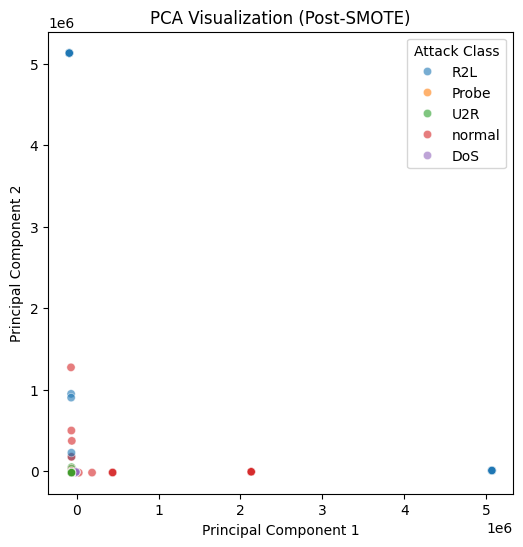

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sample_idx = X_resampled.sample(5000, random_state=42).index
X_sample = X_resampled.loc[sample_idx] #just for understanding
y_sample = y_resampled.loc[sample_idx]
# Apply PCA
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(6,6))
sns.scatterplot( x=x_pca[:,0], y=x_pca[:,1], hue=y_sample, alpha=0.6)
plt.title("PCA Visualization (Post-SMOTE)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Attack Class")
plt.show()

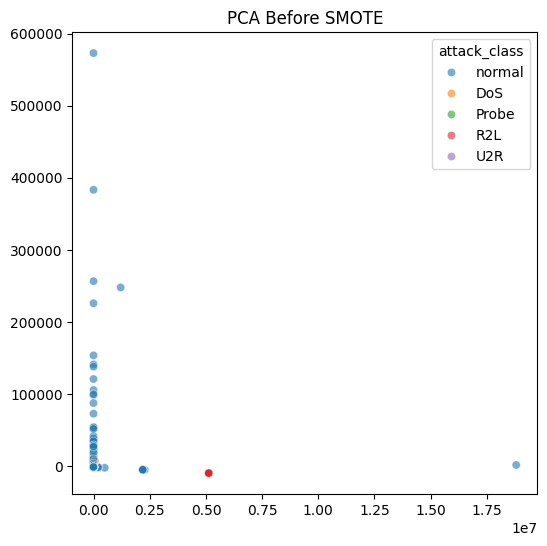

In [13]:
# Before SMOTE
sample_idx_orig = X.sample(5000, random_state=42).index
X_orig_sample = X.loc[sample_idx_orig]
y_orig_sample = y.loc[sample_idx_orig]

pca_before = PCA(n_components=2, random_state=42)
x_pca_before = pca_before.fit_transform(X_orig_sample)

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=x_pca_before[:,0],
    y=x_pca_before[:,1],
    hue=y_orig_sample,
    alpha=0.6
)

plt.title("PCA Before SMOTE")
plt.show()

In [14]:
import os
output_dir = "../data/"
os.makedirs(output_dir, exist_ok=True)
# Combine TRAIN features + target
df_final_test = pd.concat([X_resampled, y_resampled], axis=1)
# Define save path
test_save_path = os.path.join(output_dir, "test_processed_advanced.csv")

# Save file
df_final_test.to_csv(test_save_path, index=False)

print(f"Saved the Train Data to {test_save_path}")

Saved the Train Data to ../data/test_processed_advanced.csv


In [15]:
import os
output_dir = "../data/"
os.makedirs(output_dir, exist_ok=True)
# Combine TRAIN features + target
df_final_train = pd.concat([X_resampled, y_resampled], axis=1)
# Define save path
train_save_path = os.path.join(output_dir, "train_processed_advanced.csv")

# Save file
df_final_train.to_csv(train_save_path, index=False)

print(f"Saved the Train Data to {train_save_path}")

Saved the Train Data to ../data/train_processed_advanced.csv


In [16]:
import pandas as pd

df_train = pd.read_csv("../data/train_processed_advanced.csv")

print("Train shape:", df_train.shape)
df_train.head()

Train shape: (336715, 54)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,DoS
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal


In [17]:
import pandas as pd

df_train = pd.read_csv("../data/test_processed_advanced.csv")

print("Train shape:", df_train.shape)
df_train.head()

Train shape: (336715, 54)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack_class
0,0,491,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
1,0,146,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,DoS
3,0,232,8153,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal
4,0,199,420,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal


In [18]:
print(df_final_train['attack_class'].value_counts())
print(df_final_train['attack_class'].value_counts(normalize=True))

attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64
attack_class
normal    0.2
DoS       0.2
R2L       0.2
Probe     0.2
U2R       0.2
Name: proportion, dtype: float64


In [19]:
print(y_resampled.value_counts())

attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343
Name: count, dtype: int64


In [20]:
import pandas as pd
import os

print(os.listdir("data"))

df_train = pd.read_csv("../data/train_processed_advanced.csv")
df_test = pd.read_csv("../data/test_processed_advanced.csv")

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

['.ipynb_checkpoints', 'KDDTest+.txt', 'KDDTrain+.txt']
Train shape: (336715, 54)
Test shape: (336715, 54)


In [21]:
#now we separate features and target
X_train = df_train.drop("attack_class", axis=1)
y_train = df_train["attack_class"]

X_test = df_test.drop("attack_class", axis=1)
y_test = df_test["attack_class"]

In [22]:
#now we train KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
#now we will evaluate performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9969647921833004

Confusion Matrix:
 [[67271    48     0     2    22]
 [   39 67207     5    12    80]
 [    1     5 67171    89    77]
 [    0     0     7 67306    30]
 [   64   185   170   186 66738]]

Classification Report:
               precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     67343
       Probe       1.00      1.00      1.00     67343
         R2L       1.00      1.00      1.00     67343
         U2R       1.00      1.00      1.00     67343
      normal       1.00      0.99      0.99     67343

    accuracy                           1.00    336715
   macro avg       1.00      1.00      1.00    336715
weighted avg       1.00      1.00      1.00    336715



In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
# y_resampled is your target
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)

print("Classes:", le.classes_)

Classes: ['DoS' 'Probe' 'R2L' 'U2R' 'normal']


In [26]:
rf = RandomForestClassifier(
    n_estimators=100,        # number of trees
    random_state=42,         # reproducibility
    max_depth=10,            # lightweight model
    n_jobs=-1                # use all CPU cores
)

rf.fit(X_resampled, y_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [27]:
importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X_resampled.columns)

# Sort descending
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(20))

src_bytes                      0.098854
service_freq                   0.090055
dst_bytes                      0.087934
dst_host_srv_count             0.075480
logged_in                      0.045836
dst_host_same_src_port_rate    0.039324
duration                       0.038065
dst_host_diff_srv_rate         0.036889
srv_count                      0.036669
count                          0.034445
dst_host_serror_rate           0.033038
serror_rate                    0.029923
protocol_type_tcp              0.026548
dst_host_srv_serror_rate       0.025854
srv_serror_rate                0.024458
dst_host_same_srv_rate         0.023699
flag_S0                        0.022485
dst_host_count                 0.020209
hot                            0.018330
dst_host_srv_diff_host_rate    0.018017
dtype: float64


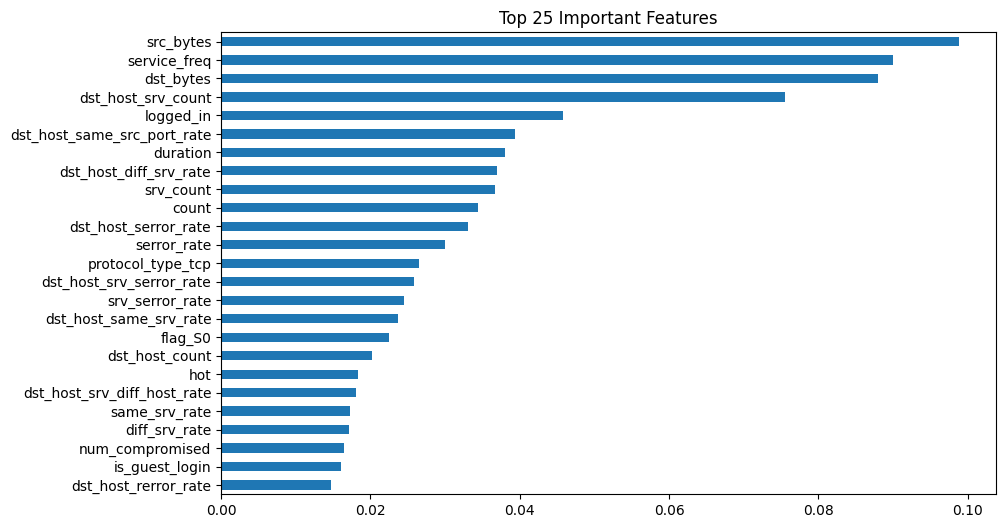

In [28]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(25)

plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 25 Important Features")
plt.show()

In [29]:
threshold = 0.001

low_importance_features = feature_importance[feature_importance < threshold]

print("Number of low importance features:", len(low_importance_features))
print(low_importance_features)

Number of low importance features: 13
flag_SH              7.244777e-04
num_access_files     3.690674e-04
num_shells           2.422783e-04
flag_S1              7.069503e-05
urgent               4.302264e-05
su_attempted         3.840327e-05
flag_RSTOS0          3.490873e-05
flag_S3              1.492449e-05
flag_S2              1.163283e-05
land                 7.693773e-06
flag_OTH             4.012455e-06
is_host_login        1.502721e-07
num_outbound_cmds    0.000000e+00
dtype: float64


In [30]:
X_selected = X_resampled.drop(columns=low_importance_features.index)

print("New shape after feature selection:", X_selected.shape)

New shape after feature selection: (336715, 40)


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

In [33]:
sample_size = min(3000, len(X_scaled))

np.random.seed(42)

rows = np.random.choice(len(X_scaled), sample_size, replace=False)

X_sample = X_scaled[rows]
y_sample = y_resampled.iloc[rows]

In [34]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=40,
    max_iter=1000,      
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

In [35]:
tsne_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "attack_type": y_sample.values
})

In [36]:
unique_attacks = tsne_df["attack_type"].unique()

color_names = [
    "blue",
    "red",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray"
]

color_dict = {
    attack: color_names[i]
    for i, attack in enumerate(unique_attacks)
}

print("Color Mapping:")
for attack, color in color_dict.items():
    print(f"{attack} → {color}")

Color Mapping:
R2L → blue
Probe → red
U2R → green
normal → orange
DoS → purple


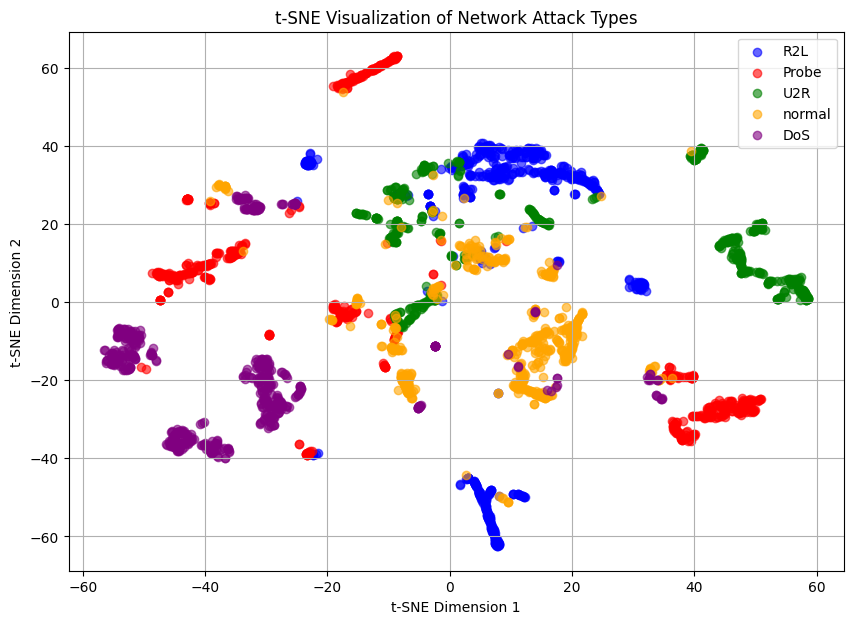

In [37]:
plt.figure(figsize=(10, 7))

for attack in unique_attacks:
    
    # Filter for each attack type
    subset = tsne_df[tsne_df["attack_type"] == attack]
    
    plt.scatter(
        subset["TSNE1"],
        subset["TSNE2"],
        c=color_dict[attack],
        label=attack,
        alpha=0.6
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE Visualization of Network Attack Types")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
import os
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("coolwarm")

In [39]:
COL_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty_level"
]

df_raw = pd.read_csv("data/KDDTrain+.txt", header=None, names=COL_NAMES)

print("Dataset shape:", df_raw.shape)
df_raw.head()

Dataset shape: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [40]:
attack_mapping = {
    "normal": "normal",

    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS",

    # Probe
    "satan": "Probe", "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",

    # R2L
    "guess_passwd": "R2L", "ftp_write": "R2L", "imap": "R2L",
    "warezmaster": "R2L", "warezclient": "R2L",

    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R"
}

df_raw["attack_class"] = df_raw["label"].map(lambda x: attack_mapping.get(x, "other"))

print(df_raw["attack_class"].value_counts())

attack_class
normal    67343
DoS       45927
Probe     11656
R2L         982
U2R          52
other        13
Name: count, dtype: int64


In [41]:
le = LabelEncoder()
y_master = le.fit_transform(df_raw["attack_class"])

print("Encoded classes:", list(le.classes_))

Encoded classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal', 'other']


In [42]:
X_raw = df_raw.drop(columns=["label", "attack_class", "difficulty_level"], errors="ignore")

print("Raw feature shape:", X_raw.shape)

Raw feature shape: (125973, 41)


In [43]:
numeric_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns
X_numeric = X_raw[numeric_cols]

print("Number of numeric columns:", len(numeric_cols))
print("Numeric data shape:", X_numeric.shape)

Number of numeric columns: 38
Numeric data shape: (125973, 38)


In [44]:
preprocessing_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [45]:

#fit and transform
X_processed = preprocessing_pipeline.fit_transform(X_numeric)

print("Before preprocessing shape :", X_numeric.shape)
print("After preprocessing shape  :", X_processed.shape)

Before preprocessing shape : (125973, 38)
After preprocessing shape  : (125973, 38)


In [47]:
prep_engine = joblib.load("models/preprocessing_engine.joblib")
label_encoder = joblib.load("models/label_encoder.pkl")

print("Prep engine loaded successfully.")

Prep engine loaded successfully.


In [48]:
# Step 1: check which columns pipeline expects
expected_cols = prep_engine.feature_names_in_

# Step 2: select those columns from your encoded dataset
X_numeric_again = X_resampled[expected_cols]

# Step 3: apply preprocessing pipeline
X_signal = prep_engine.transform(X_numeric_again)

# Step 4: check shapes
print("\n--- Connection Architecture ---")
print("Pre-Selection Features :", X_numeric_again.shape[1])
print("Post-Selection Signal  :", X_signal.shape[1])


--- Connection Architecture ---
Pre-Selection Features : 53
Post-Selection Signal  : 20


In [49]:
le = LabelEncoder()
y_master = le.fit_transform(y_resampled)

print("Encoded classes:", list(le.classes_))

Encoded classes: ['DoS', 'Probe', 'R2L', 'U2R', 'normal']


In [50]:
from sklearn.ensemble import IsolationForest

print("\n### ANALYZING NORMALCY BASELINES ###")

iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(X_signal)

iso_score = iso.decision_function(X_signal)
iso_pred = iso.predict(X_signal)

analysis_df = pd.DataFrame({
    "attack_class": y_resampled.values,
    "iso_score": iso_score,
    "iso_pred": iso_pred
})

analysis_df["is_anomaly"] = analysis_df["iso_pred"].map({1: 0, -1: 1})

print("Isolation Forest completed.")
print(analysis_df.head())


### ANALYZING NORMALCY BASELINES ###
Isolation Forest completed.
  attack_class  iso_score  iso_pred  is_anomaly
0       normal   0.233051         1           0
1       normal   0.140458         1           0
2          DoS   0.211652         1           0
3       normal   0.216665         1           0
4       normal   0.208869         1           0


In [51]:
print("len(y_resampled):", len(y_resampled))
print("len(iso_score):", len(iso_score))
print("len(iso_pred):", len(iso_pred))
print("len(X_signal):", len(X_signal))

len(y_resampled): 336715
len(iso_score): 336715
len(iso_pred): 336715
len(X_signal): 336715


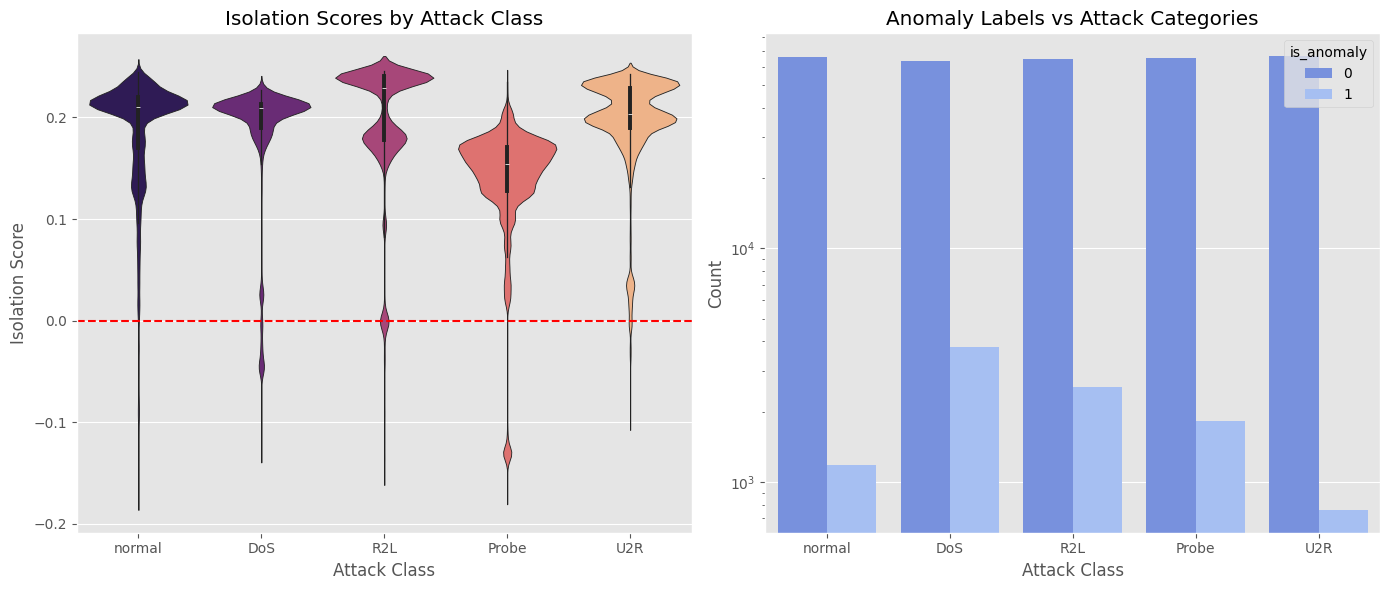

In [52]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x="attack_class", y="iso_score", data=analysis_df, palette="magma")
plt.axhline(0, color="red", linestyle="--")
plt.title("Isolation Scores by Attack Class")
plt.xlabel("Attack Class")
plt.ylabel("Isolation Score")

plt.subplot(1, 2, 2)
sns.countplot(x="attack_class", hue="is_anomaly", data=analysis_df)
plt.title("Anomaly Labels vs Attack Categories")
plt.yscale("log")
plt.xlabel("Attack Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
   X_signal,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (269372, 20)
Testing data shape: (67343, 20)


In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [55]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}


In [56]:
y_pred = best_model.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [58]:
from sklearn.metrics import accuracy_score, f1_score

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1 Score:", f1_score(y_test, y_pred, average="macro"))

Model Accuracy: 0.9982774750159631
Macro F1 Score: 0.9982772889653673


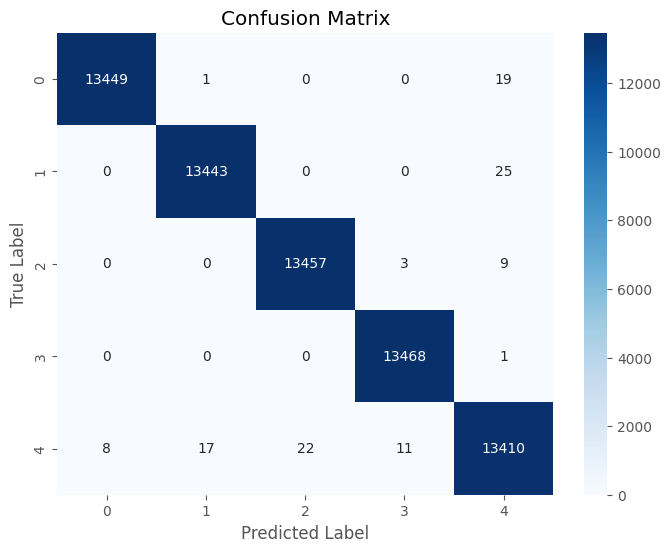

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [60]:
report = classification_report(y_test, y_pred, output_dict=True)

audit_df = pd.DataFrame(report).transpose()

print(audit_df)

              precision    recall  f1-score       support
DoS            0.999406  0.998515  0.998960  13469.000000
Probe          0.998663  0.998144  0.998403  13468.000000
R2L            0.998368  0.999109  0.998738  13469.000000
U2R            0.998962  0.999926  0.999443  13469.000000
normal         0.995989  0.995693  0.995841  13468.000000
accuracy       0.998277  0.998277  0.998277      0.998277
macro avg      0.998277  0.998277  0.998277  67343.000000
weighted avg   0.998277  0.998277  0.998277  67343.000000


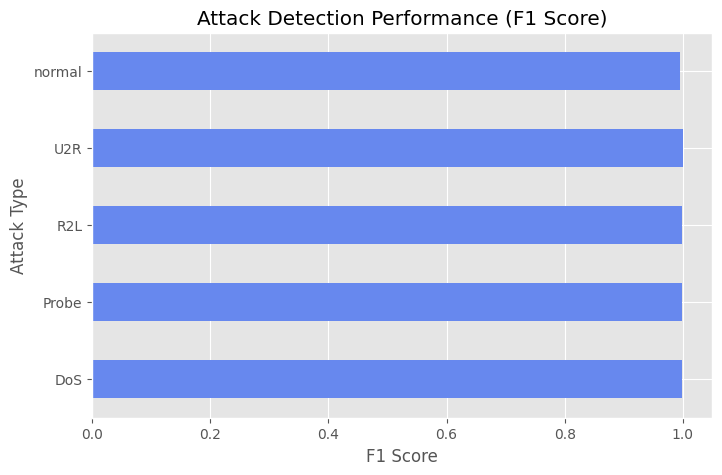

In [61]:
audit_df.iloc[:-3]["f1-score"].plot(kind="barh", figsize=(8,5))

plt.title("Attack Detection Performance (F1 Score)")
plt.xlabel("F1 Score")
plt.ylabel("Attack Type")

plt.show()

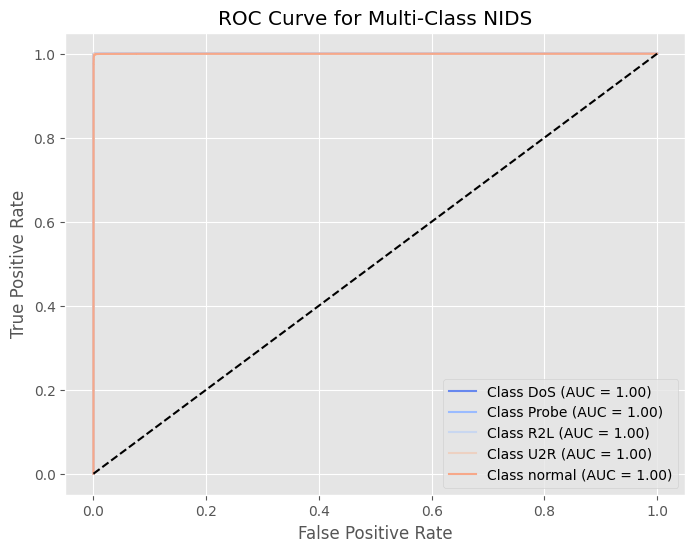

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

classes = best_model.classes_
y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Multi-Class NIDS")
plt.legend()
plt.show()

In [63]:
print("Train accuracy:", best_model.score(X_train, y_train))
print("Test accuracy :", best_model.score(X_test, y_test))

Train accuracy: 0.9998700681585317
Test accuracy : 0.9982774750159631
